## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Payton Gergen

**Date:** 9/30/26

### Question 1

1. Regression predicts a numeric outcome, whereas classification predicts what category an object would fall in.

2. A confusion table counts predictions from classification by actual and predicted class. It shows for which groups the classification algorithm has a high accuracy and where it has low accuracy.

3. SSE is the sum of the squared residuals. Lower SSE indicates smaller errors.

4. Overfitting occurs when the value of k is too small, and it makes too many classifications based on noise. Underfitting occurs when the value of k is too large, and it provides too few predictions, grouping predictions that should not be grouped together.

5. Splitting into training and testing sets ensures that the model is validated for accuracy on a different set of data than it was trained on, measuring whether then model is generalizable beyond the training data. A model can fit its training data well by fitting noise in the sample, so selecting a value of k based on the separate validation dataset improves model performance.

6. Reporting a class label as a prediction can be useful when you need to make a single decision. However, predictions can abruptly change. Reporting the probability distribution over class labels can demonstrate where uncertainty takes place and show where there are multiple similarly likely labels.

### Question 2: Predict mine type

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Part 1: Load and examine data

In [52]:
mines = pd.read_csv("data/land_mines.csv")
mines

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
...,...,...,...,...
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5


(array([ 45., 123.,  62.,  42.,  19.,  10.,   7.,   4.,   5.,  21.]),
 array([0.19773388, 0.27796036, 0.35818685, 0.43841333, 0.51863982,
        0.5988663 , 0.67909279, 0.75931927, 0.83954576, 0.91977224,
        0.99999873]),
 <BarContainer object of 10 artists>)

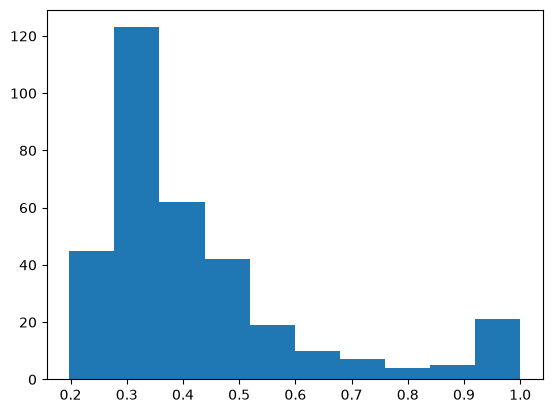

In [53]:
plt.hist(mines["voltage"])

Voltage falls withhin 0 and 1, with most of the data being below 0.6.

(array([49., 30., 28., 29., 29., 30., 30., 29., 29., 55.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

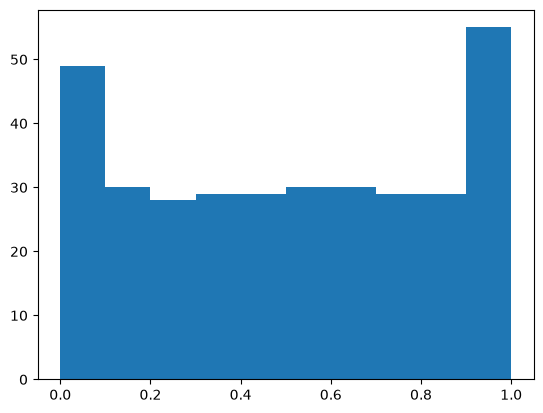

In [54]:
plt.hist(mines["height"])

Height is approximately uniformly distributed from 0 to 1.

(array([59.,  0., 51.,  0., 56., 57.,  0.,  0., 58., 57.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

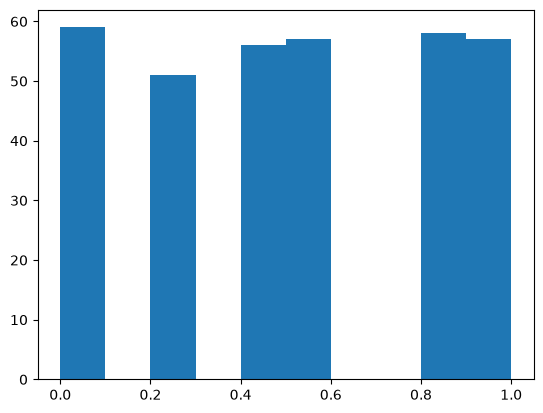

In [55]:
plt.hist(mines["soil"])

In [56]:
mines["soil"].unique()

array([0. , 0.6, 0.2, 0.8, 0.4, 1. ])

Soil takes on a value of 0, 0.2, 0.4, 0.6, 0.8, or 1.

(array([71.,  0., 70.,  0.,  0., 66.,  0., 66.,  0., 65.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

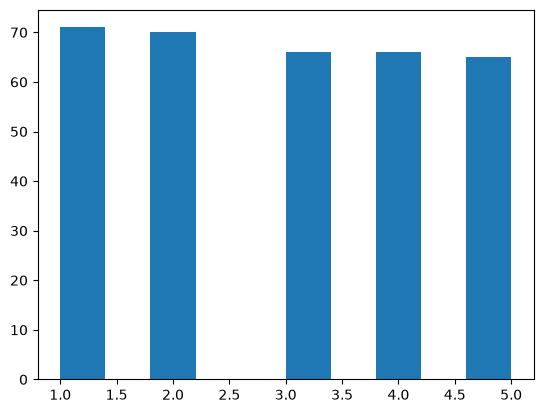

In [57]:
plt.hist(mines["mine_type"])

In [58]:
mines["mine_type"].unique()

array([1, 2, 3, 4, 5])

All mine types are 1, 2, 3, 4, or 5, with each value having about the same number of mines.

#### Part 2: Split training and validation sets

In [59]:
eval_X_raw = mines[["voltage", "height", "soil"]] # Training variables
eval_y = mines["mine_type"] # Target variable

# Split data
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.5, random_state = 10
)

# Scale data
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.fit_transform(eval_X_valid_raw)

#### Part 3: Build kNN classifier

In [60]:
# We expect the optimal k value to be around the square root of N
np.sqrt(len(mines))

np.float64(18.384776310850235)

In [61]:
eval_ks = np.arange(1,30) # Test values of k between 10 and 30

eval_valid_sse = []
eval_train_sse = []

for k in eval_ks: # Test out each value of k in eval_ks to deteremine which one minimizes validation SSE
    eval_candidate = KNeighborsRegressor(n_neighbors = int(k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_prediction = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_prediction = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum((eval_y_valid.to_numpy() - eval_valid_prediction) ** 2)) # Calculate and append validation SSE
    eval_train_sse.append(np.sum((eval_y_train.to_numpy() - eval_train_prediction) ** 2)) # Calculuate and append training SSE

optimal_k = int(eval_ks[np.argmin(eval_valid_sse)])
optimal_k

15

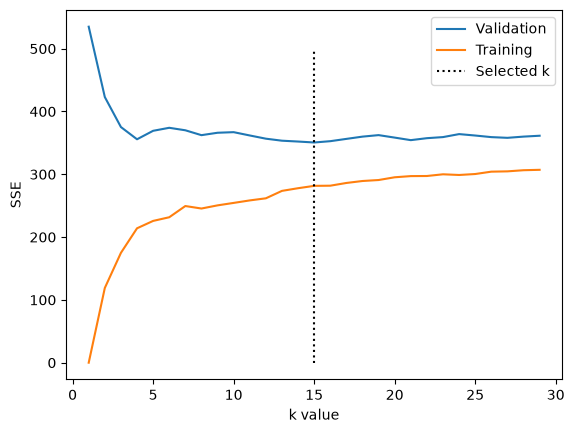

In [62]:
# Plot training and validation SSEs

plt.plot(eval_ks, eval_valid_sse, label = "Validation")
plt.plot(eval_ks, eval_train_sse, label = "Training")

plt.vlines(15, ymin = 0, ymax = 500, color = "black", label = "Selected k", linestyles=":")

plt.xlabel("k value")
plt.ylabel("SSE")
plt.legend()

The value of k was selected by testing integers from 1 to 30. A model was fit for each value of k, and the SSE was calculated for the training and validation sets. The optimal k value was selected by identifying the value that minimized the validation SSE.

In [63]:
classification_X_raw = mines[["voltage", "height", "soil"]]
classification_y = mines["mine_type"]

classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=15).fit(
    classification_X_scaled, classification_y
)

#### Part 4: Confusion Table

In [64]:
y_pred = classification_model.predict(classification_X_scaled)
confusion = confusion_matrix(classification_y, y_pred)
confusion

array([[66,  0,  4,  0,  1],
       [ 0, 65,  2,  3,  0],
       [ 9,  2, 31,  9, 15],
       [26,  3, 14, 16,  7],
       [16,  0, 22,  8, 19]])

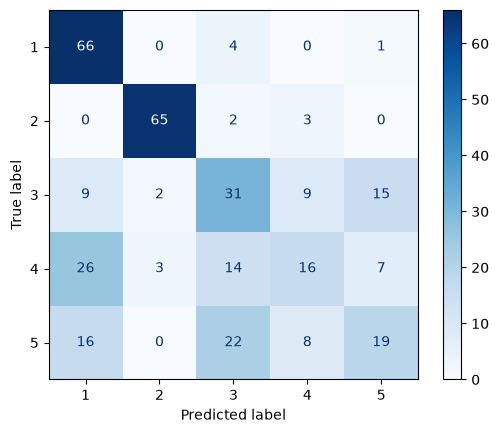

In [65]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["1", "2", "3", "4", "5"])
disp.plot(cmap="Blues")
plt.grid(False)
plt.show()

In [66]:
(66+65+31+16+19) / confusion.sum()

np.float64(0.5828402366863905)

The confusion matrix indicates that the model correctly predicted 58% of the mine types. It did a good job of predicting type 2, but it performed poorly for the other types. Because this would be used for potentially high-risk tasks relating to land mines, I would caution against reliance on this model.

#### Part 5: Advice on model use

If you want to identify type 2, this is a good model to use. Otherwise, I  would use the model knowing that there will be a high percent of errors.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [67]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]